In [1]:
import torch

print("PyTorch version:", torch.__version__)

if torch.cuda.is_available():
    print("GPU is ready!")
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU is NOT enabled.")

PyTorch version: 2.11.0+cu128
GPU is ready!
GPU: Tesla T4


In [2]:
!git clone https://github.com/spMohanty/PlantVillage-Dataset.git

Cloning into 'PlantVillage-Dataset'...
remote: Enumerating objects: 163264, done.
remote: Counting objects: 100% (35/35), done.
remote: Compressing objects: 100% (26/26), done.
remote: Total 163264 (delta 16), reused 25 (delta 9), pack-reused 163229 (from 1)
Receiving objects: 100% (163264/163264), 2.00 GiB | 17.31 MiB/s, done.
Resolving deltas: 100% (115/115), done.
Updating files: 100% (182404/182404), done.


In [3]:
import os

dataset_path = "/content/PlantVillage-Dataset/raw/color"

print("Dataset exists:", os.path.exists(dataset_path))

if os.path.exists(dataset_path):
    classes = os.listdir(dataset_path)
    print("Number of classes:", len(classes))
    print("\nFirst 10 classes:")

    for class_name in classes[:10]:
        print(class_name)

Dataset exists: True
Number of classes: 38

First 10 classes:
Cherry_(including_sour)___healthy
Peach___Bacterial_spot
Tomato___Bacterial_spot
Potato___healthy
Apple___healthy
Soybean___healthy
Strawberry___healthy
Grape___Black_rot
Cherry_(including_sour)___Powdery_mildew
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)


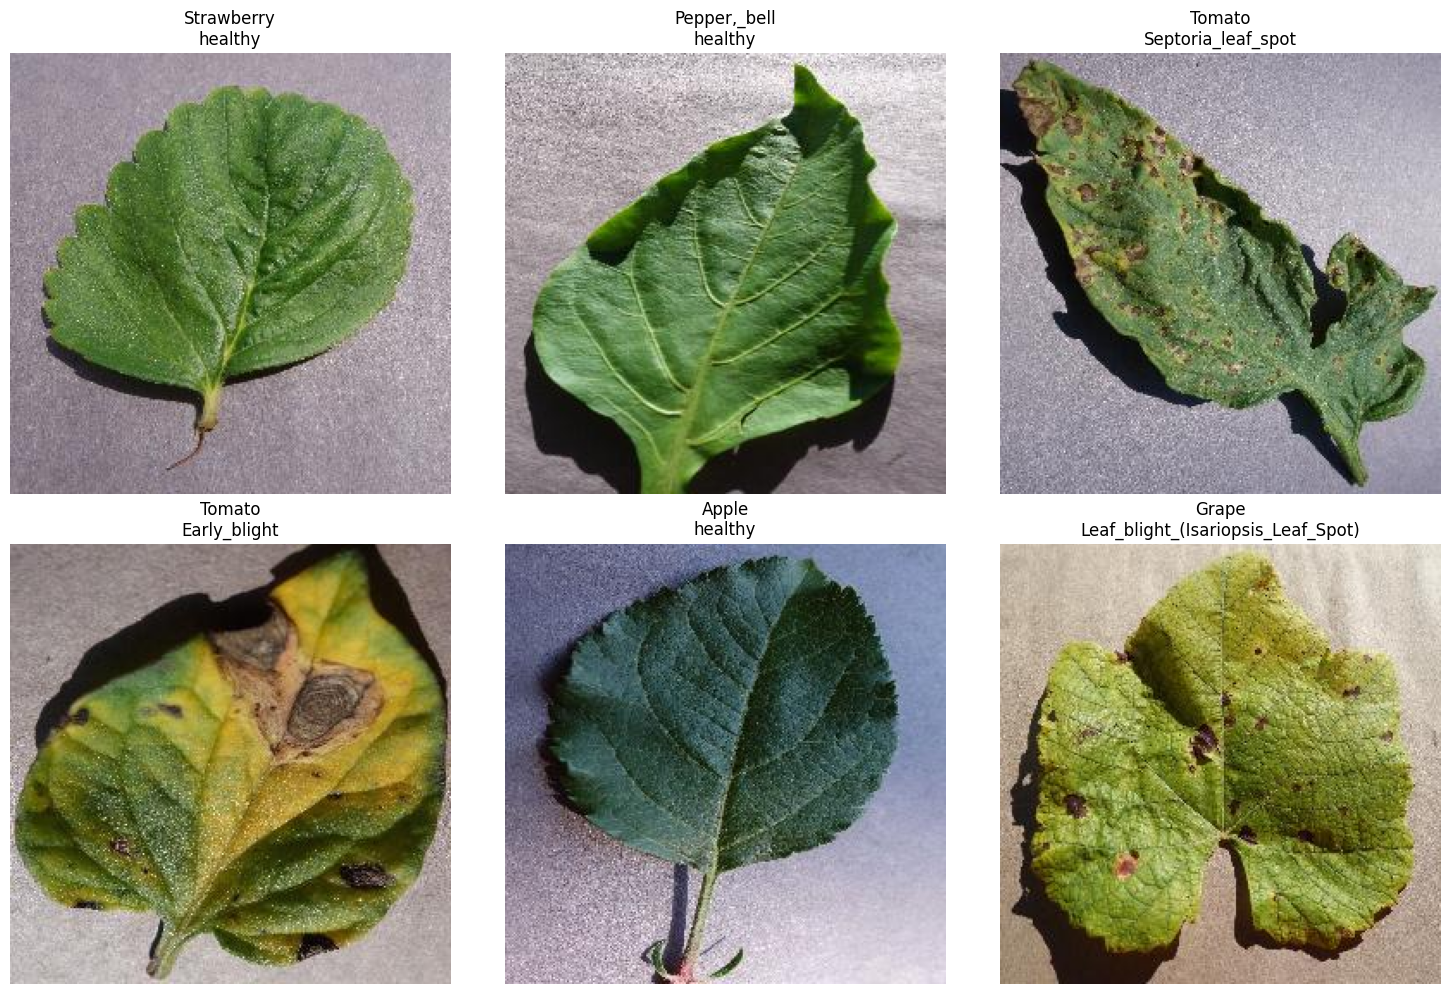

In [4]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

# Pick 6 random disease classes
selected_classes = random.sample(classes, 6)

plt.figure(figsize=(15, 10))

for i, class_name in enumerate(selected_classes):
    class_path = os.path.join(dataset_path, class_name)

    # Get all images from this class
    images = os.listdir(class_path)

    # Pick one random image
    image_name = random.choice(images)
    image_path = os.path.join(class_path, image_name)

    # Open the image
    image = Image.open(image_path)

    # Display it
    plt.subplot(2, 3, i + 1)
    plt.imshow(image)
    plt.title(class_name.replace("___", "\n"))
    plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
# Count how many images are in each class

class_counts = {}

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)

    images = [
        file for file in os.listdir(class_path)
        if file.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    class_counts[class_name] = len(images)

# Total number of images
total_images = sum(class_counts.values())

print("Total number of images:", total_images)
print("Number of classes:", len(class_counts))

print("\nImages in each class:\n")

for class_name, count in sorted(class_counts.items()):
    print(f"{class_name}: {count}")

Total number of images: 54305
Number of classes: 38

Images in each class:

Apple___Apple_scab: 630
Apple___Black_rot: 621
Apple___Cedar_apple_rust: 275
Apple___healthy: 1645
Blueberry___healthy: 1502
Cherry_(including_sour)___Powdery_mildew: 1052
Cherry_(including_sour)___healthy: 854
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 513
Corn_(maize)___Common_rust_: 1192
Corn_(maize)___Northern_Leaf_Blight: 985
Corn_(maize)___healthy: 1162
Grape___Black_rot: 1180
Grape___Esca_(Black_Measles): 1383
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 1076
Grape___healthy: 423
Orange___Haunglongbing_(Citrus_greening): 5507
Peach___Bacterial_spot: 2297
Peach___healthy: 360
Pepper,_bell___Bacterial_spot: 997
Pepper,_bell___healthy: 1478
Potato___Early_blight: 1000
Potato___Late_blight: 1000
Potato___healthy: 152
Raspberry___healthy: 371
Soybean___healthy: 5090
Squash___Powdery_mildew: 1835
Strawberry___Leaf_scorch: 1109
Strawberry___healthy: 456
Tomato___Bacterial_spot: 2127
Tomato___Early_bligh

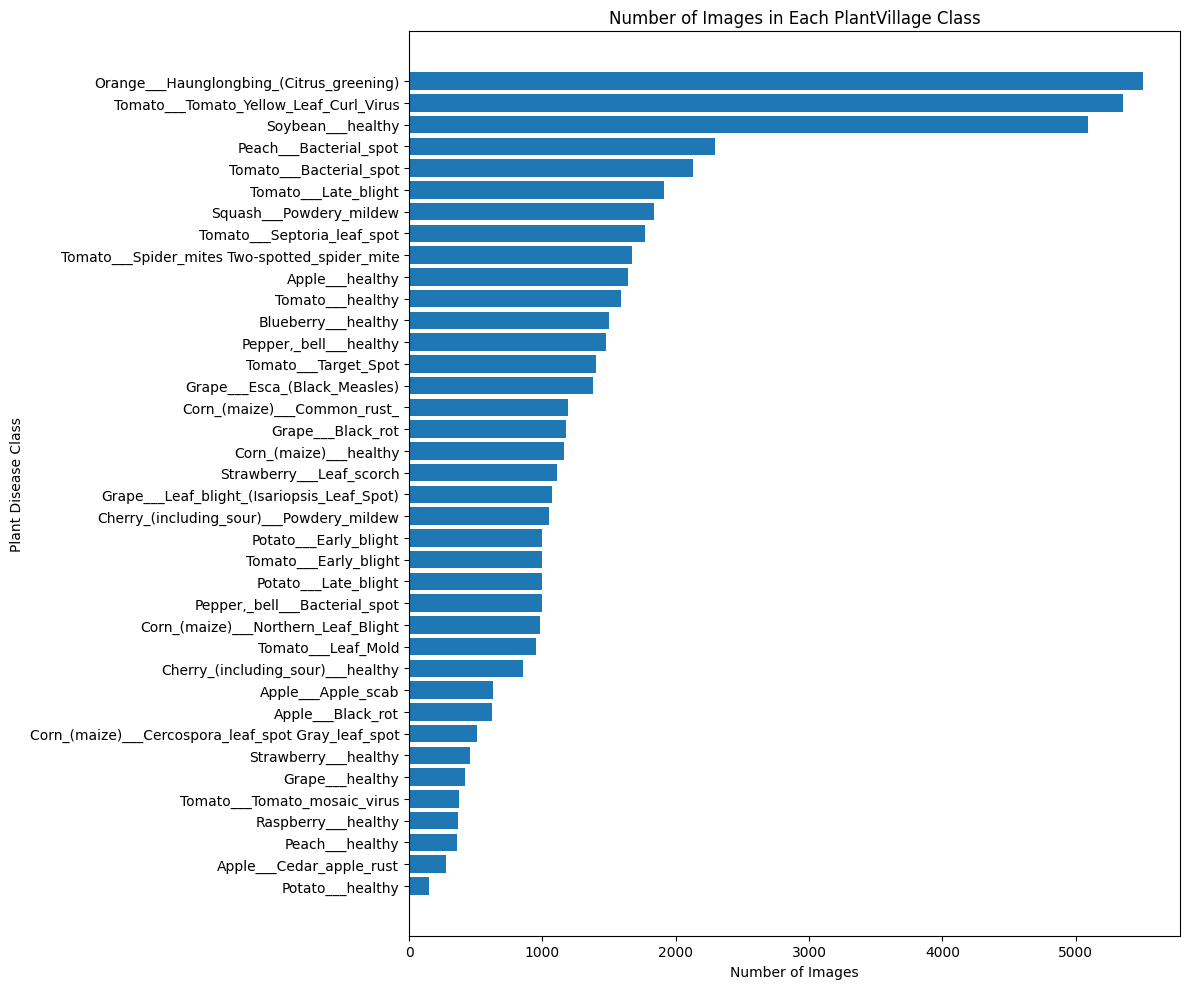

In [6]:
# Create a graph showing the number of images in each class

import matplotlib.pyplot as plt

# Sort classes by number of images
sorted_counts = dict(
    sorted(class_counts.items(), key=lambda item: item[1])
)

plt.figure(figsize=(12, 10))

plt.barh(
    list(sorted_counts.keys()),
    list(sorted_counts.values())
)

plt.xlabel("Number of Images")
plt.ylabel("Plant Disease Class")
plt.title("Number of Images in Each PlantVillage Class")

plt.tight_layout()
plt.show()

In [7]:
import os
import random
import shutil

# Make our experiment reproducible
random.seed(42)

# Original dataset
source_dir = dataset_path

# New folder for our split dataset
split_dir = "/content/plant_dataset_split"

train_dir = os.path.join(split_dir, "train")
val_dir = os.path.join(split_dir, "val")
test_dir = os.path.join(split_dir, "test")

# Remove old split folder if this cell was run before
if os.path.exists(split_dir):
    shutil.rmtree(split_dir)

# Create folders
os.makedirs(train_dir)
os.makedirs(val_dir)
os.makedirs(test_dir)

# Split each class separately
for class_name in classes:

    class_source = os.path.join(source_dir, class_name)

    images = [
        f for f in os.listdir(class_source)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    # Shuffle images randomly
    random.shuffle(images)

    total = len(images)

    train_end = int(0.70 * total)
    val_end = train_end + int(0.15 * total)

    train_images = images[:train_end]
    val_images = images[train_end:val_end]
    test_images = images[val_end:]

    # Create this class inside train/val/test
    os.makedirs(os.path.join(train_dir, class_name))
    os.makedirs(os.path.join(val_dir, class_name))
    os.makedirs(os.path.join(test_dir, class_name))

    # Copy training images
    for image in train_images:
        shutil.copy(
            os.path.join(class_source, image),
            os.path.join(train_dir, class_name, image)
        )

    # Copy validation images
    for image in val_images:
        shutil.copy(
            os.path.join(class_source, image),
            os.path.join(val_dir, class_name, image)
        )

    # Copy testing images
    for image in test_images:
        shutil.copy(
            os.path.join(class_source, image),
            os.path.join(test_dir, class_name, image)
        )

print("Dataset split completed!")

Dataset split completed!


In [8]:
def count_images(folder):
    total = 0

    for class_name in os.listdir(folder):
        class_folder = os.path.join(folder, class_name)

        if os.path.isdir(class_folder):
            total += len([
                f for f in os.listdir(class_folder)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])

    return total


train_count = count_images(train_dir)
val_count = count_images(val_dir)
test_count = count_images(test_dir)

total_count = train_count + val_count + test_count

print("Training images:", train_count)
print("Validation images:", val_count)
print("Testing images:", test_count)
print("-----------------------")
print("Total images:", total_count)

print("\nPercentages:")
print(f"Training:   {train_count / total_count * 100:.2f}%")
print(f"Validation: {val_count / total_count * 100:.2f}%")
print(f"Testing:    {test_count / total_count * 100:.2f}%")

Training images: 37997
Validation images: 8129
Testing images: 8179
-----------------------
Total images: 54305

Percentages:
Training:   69.97%
Validation: 14.97%
Testing:    15.06%


In [9]:
import torch
from torchvision import datasets, transforms

# Image size that we will use
IMAGE_SIZE = 224

# For now, NO augmentation.
# This will be our baseline preprocessing.
baseline_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Baseline image preprocessing created!")

Baseline image preprocessing created!


In [10]:
train_dataset = datasets.ImageFolder(
    train_dir,
    transform=baseline_transform
)

val_dataset = datasets.ImageFolder(
    val_dir,
    transform=baseline_transform
)

test_dataset = datasets.ImageFolder(
    test_dir,
    transform=baseline_transform
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Testing images:", len(test_dataset))

print("\nNumber of classes:", len(train_dataset.classes))

print("\nFirst 10 classes:")
for class_name in train_dataset.classes[:10]:
    print(class_name)

Training images: 37997
Validation images: 8129
Testing images: 8179

Number of classes: 38

First 10 classes:
Apple___Apple_scab
Apple___Black_rot
Apple___Cedar_apple_rust
Apple___healthy
Blueberry___healthy
Cherry_(including_sour)___Powdery_mildew
Cherry_(including_sour)___healthy
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
Corn_(maize)___Common_rust_
Corn_(maize)___Northern_Leaf_Blight


In [11]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)

print("DataLoaders created successfully!")
print("Batch size:", BATCH_SIZE)

DataLoaders created successfully!
Batch size: 32


In [12]:
import torch
import torch.nn as nn

class SimpleCNN(nn.Module):

    def __init__(self, num_classes=38):
        super(SimpleCNN, self).__init__()

        # Part 1: Learn features from leaf images
        self.features = nn.Sequential(

            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        # Part 2: Make the final prediction
        self.classifier = nn.Sequential(

            nn.Flatten(),

            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),

            nn.Dropout(0.5),

            nn.Linear(256, num_classes)
        )

    def forward(self, x):

        x = self.features(x)
        x = self.classifier(x)

        return x


print("SimpleCNN model created!")

SimpleCNN model created!


In [13]:
# Choose GPU if available
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

# Create our CNN
model = SimpleCNN(
    num_classes=len(train_dataset.classes)
)

# Move model to GPU
model = model.to(device)

print("Model moved to:", device)

Using device: cuda
Model moved to: cuda


In [14]:
# Get one batch of images
images, labels = next(iter(train_loader))

print("Images shape:", images.shape)
print("Labels shape:", labels.shape)

# Move images to GPU
images = images.to(device)

# Pass them through our CNN
outputs = model(images)

print("Model output shape:", outputs.shape)

Images shape: torch.Size([32, 3, 224, 224])
Labels shape: torch.Size([32])
Model output shape: torch.Size([32, 38])


In [15]:
import torch.optim as optim

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    model.parameters(),
    lr=0.001
)

# Number of training epochs
NUM_EPOCHS = 5

print("Training setup complete!")
print("Loss function: CrossEntropyLoss")
print("Optimizer: Adam")
print("Learning rate: 0.001")
print("Epochs:", NUM_EPOCHS)

Training setup complete!
Loss function: CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001
Epochs: 5


In [16]:
# Store results for graphs later
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(NUM_EPOCHS):

    # =========================
    # TRAINING
    # =========================
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        optimizer.zero_grad()

        # Make predictions
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model
        optimizer.step()

        running_loss += loss.item()

        # Calculate training accuracy
        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_loader)
    train_accuracy = 100 * correct / total


    # =========================
    # VALIDATION
    # =========================
    model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            val_running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(val_loader)
    val_accuracy = 100 * val_correct / val_total


    # Save results
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)


    # Show progress
    print(f"Epoch [{epoch+1}/{NUM_EPOCHS}]")
    print(f"Training Loss: {train_loss:.4f}")
    print(f"Training Accuracy: {train_accuracy:.2f}%")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.2f}%")
    print("-" * 40)

print("Training finished!")

Epoch [1/5]
Training Loss: 1.2476
Training Accuracy: 63.85%
Validation Loss: 0.4685
Validation Accuracy: 85.87%
----------------------------------------
Epoch [2/5]
Training Loss: 0.5857
Training Accuracy: 81.80%
Validation Loss: 0.3106
Validation Accuracy: 90.44%
----------------------------------------
Epoch [3/5]
Training Loss: 0.4068
Training Accuracy: 87.22%
Validation Loss: 0.2274
Validation Accuracy: 92.78%
----------------------------------------
Epoch [4/5]
Training Loss: 0.2974
Training Accuracy: 90.55%
Validation Loss: 0.2901
Validation Accuracy: 91.13%
----------------------------------------
Epoch [5/5]
Training Loss: 0.2400
Training Accuracy: 92.20%
Validation Loss: 0.2308
Validation Accuracy: 93.18%
----------------------------------------
Training finished!


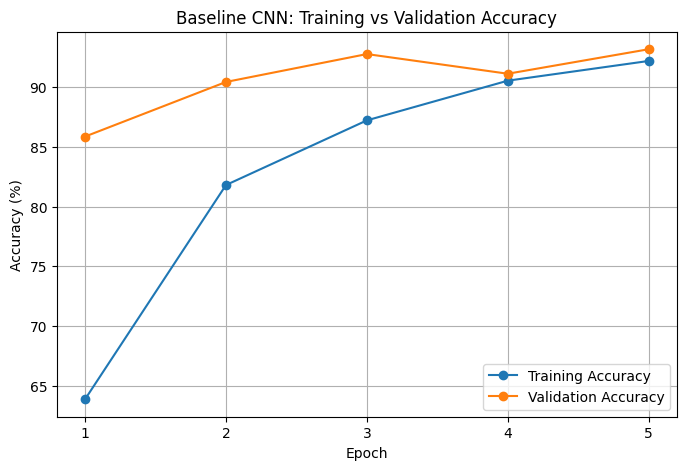

In [17]:
import matplotlib.pyplot as plt

epochs = range(1, NUM_EPOCHS + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs, train_accuracies, marker="o", label="Training Accuracy")
plt.plot(epochs, val_accuracies, marker="o", label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Baseline CNN: Training vs Validation Accuracy")

plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.show()

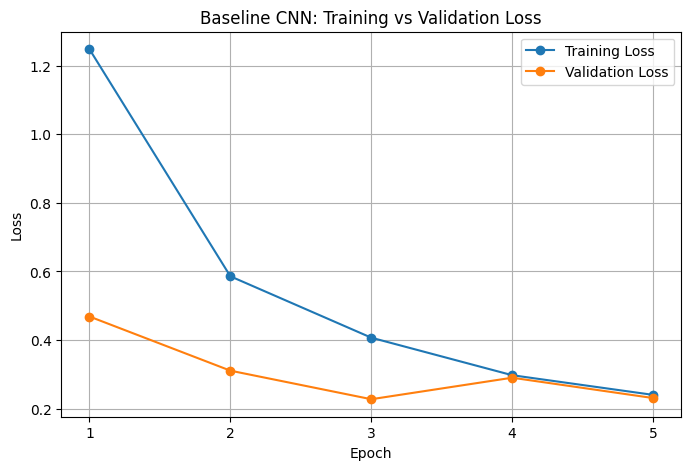

In [18]:
plt.figure(figsize=(8, 5))

plt.plot(epochs, train_losses, marker="o", label="Training Loss")
plt.plot(epochs, val_losses, marker="o", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Baseline CNN: Training vs Validation Loss")

plt.xticks(epochs)
plt.legend()
plt.grid(True)

plt.show()

In [19]:
torch.save(
    model.state_dict(),
    "/content/baseline_cnn.pth"
)

print("Baseline CNN saved successfully!")

Baseline CNN saved successfully!


In [20]:
model.eval()

test_correct = 0
test_total = 0
test_running_loss = 0.0

all_labels = []
all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Make predictions
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)
        test_running_loss += loss.item()

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        test_total += labels.size(0)
        test_correct += (predicted == labels).sum().item()

        # Save predictions for later analysis
        all_labels.extend(labels.cpu().numpy())
        all_predictions.extend(predicted.cpu().numpy())


test_loss = test_running_loss / len(test_loader)
test_accuracy = 100 * test_correct / test_total

print("BASELINE CNN TEST RESULTS")
print("-------------------------")
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")
print(f"Correct Predictions: {test_correct}")
print(f"Total Test Images: {test_total}")

BASELINE CNN TEST RESULTS
-------------------------
Test Loss: 0.2137
Test Accuracy: 93.74%
Correct Predictions: 7667
Total Test Images: 8179


In [21]:
from sklearn.metrics import classification_report

class_names = test_dataset.classes

report = classification_report(
    all_labels,
    all_predictions,
    target_names=class_names,
    digits=4
)

print(report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9254    0.6526    0.7654        95
                                 Apple___Black_rot     0.9545    0.8936    0.9231        94
                          Apple___Cedar_apple_rust     1.0000    0.7381    0.8493        42
                                   Apple___healthy     0.9534    0.9073    0.9298       248
                               Blueberry___healthy     0.8876    0.9779    0.9305       226
          Cherry_(including_sour)___Powdery_mildew     0.9455    0.9811    0.9630       159
                 Cherry_(including_sour)___healthy     0.9470    0.9690    0.9579       129
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.7143    0.8333    0.7692        78
                       Corn_(maize)___Common_rust_     0.9780    0.9889    0.9834       180
               Corn_(maize)___Northern_Leaf_Blight     0.9370    0.7987    0.86

In [22]:
from sklearn.metrics import precision_score, recall_score, f1_score

macro_precision = precision_score(
    all_labels,
    all_predictions,
    average="macro"
)

macro_recall = recall_score(
    all_labels,
    all_predictions,
    average="macro"
)

macro_f1 = f1_score(
    all_labels,
    all_predictions,
    average="macro"
)

weighted_f1 = f1_score(
    all_labels,
    all_predictions,
    average="weighted"
)

print("BASELINE CNN - OVERALL METRICS")
print("--------------------------------")
print(f"Test Accuracy:       {test_accuracy:.2f}%")
print(f"Macro Precision:     {macro_precision:.4f}")
print(f"Macro Recall:        {macro_recall:.4f}")
print(f"Macro F1-score:      {macro_f1:.4f}")
print(f"Weighted F1-score:   {weighted_f1:.4f}")

BASELINE CNN - OVERALL METRICS
--------------------------------
Test Accuracy:       93.74%
Macro Precision:     0.9237
Macro Recall:        0.9087
Macro F1-score:      0.9128
Weighted F1-score:   0.9362


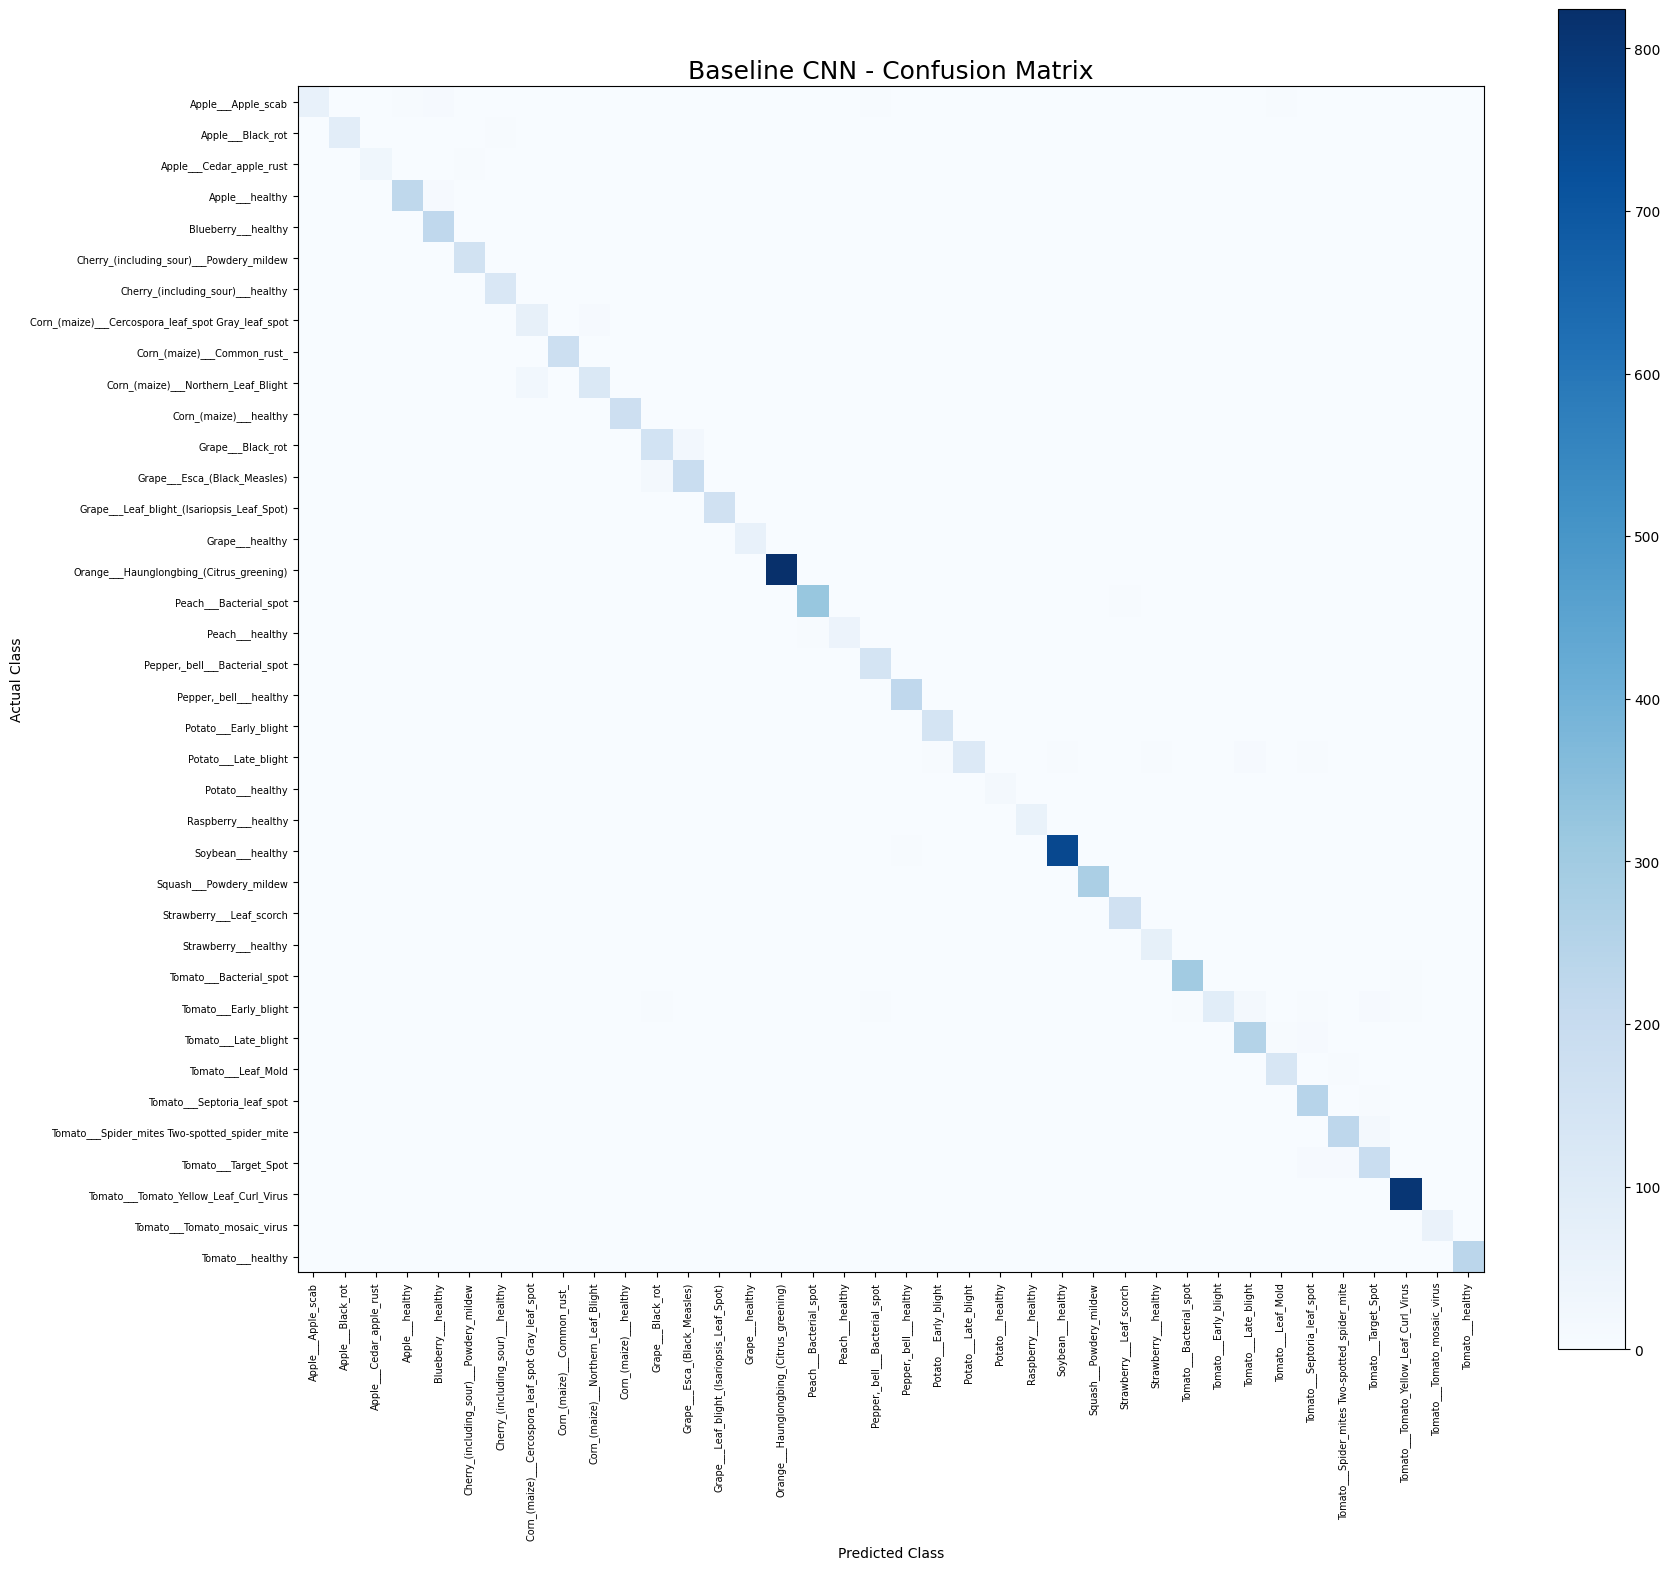

In [23]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Create confusion matrix
cm = confusion_matrix(all_labels, all_predictions)

plt.figure(figsize=(18, 16))

plt.imshow(cm, interpolation="nearest", cmap="Blues")

plt.title("Baseline CNN - Confusion Matrix", fontsize=18)
plt.colorbar()

tick_marks = np.arange(len(class_names))

plt.xticks(
    tick_marks,
    class_names,
    rotation=90,
    fontsize=7
)

plt.yticks(
    tick_marks,
    class_names,
    fontsize=7
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()
plt.show()

In [24]:
# Find the most common incorrect predictions

mistakes = []

for actual in range(len(class_names)):
    for predicted in range(len(class_names)):

        # Ignore correct predictions
        if actual != predicted:

            count = cm[actual, predicted]

            if count > 0:
                mistakes.append(
                    (
                        count,
                        class_names[actual],
                        class_names[predicted]
                    )
                )

# Sort from biggest mistake to smallest
mistakes.sort(reverse=True)

print("TOP 10 MODEL CONFUSIONS")
print("-------------------------------------------")

for i, (count, actual, predicted) in enumerate(mistakes[:10], 1):

    print(f"{i}. Actual: {actual}")
    print(f"   Predicted as: {predicted}")
    print(f"   Number of mistakes: {count}")
    print()

TOP 10 MODEL CONFUSIONS
-------------------------------------------
1. Actual: Corn_(maize)___Northern_Leaf_Blight
   Predicted as: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
   Number of mistakes: 25

2. Actual: Grape___Black_rot
   Predicted as: Grape___Esca_(Black_Measles)
   Number of mistakes: 22

3. Actual: Tomato___Early_blight
   Predicted as: Tomato___Late_blight
   Number of mistakes: 19

4. Actual: Tomato___Spider_mites Two-spotted_spider_mite
   Predicted as: Tomato___Target_Spot
   Number of mistakes: 16

5. Actual: Grape___Esca_(Black_Measles)
   Predicted as: Grape___Black_rot
   Number of mistakes: 14

6. Actual: Tomato___Target_Spot
   Predicted as: Tomato___Septoria_leaf_spot
   Number of mistakes: 9

7. Actual: Potato___Late_blight
   Predicted as: Tomato___Late_blight
   Number of mistakes: 9

8. Actual: Tomato___Target_Spot
   Predicted as: Tomato___Spider_mites Two-spotted_spider_mite
   Number of mistakes: 8

9. Actual: Apple___healthy
   Predicted as: Bl

In [25]:
# STEP 17: Display misclassified test images

import matplotlib.pyplot as plt
import torch

model.eval()

wrong_images = []
wrong_actual = []
wrong_predicted = []

# Look through the test dataset
with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs, 1)

        # Check each image in this batch
        for i in range(len(labels)):

            if predictions[i] != labels[i]:

                wrong_images.append(images[i].cpu())

                wrong_actual.append(
                    class_names[labels[i].item()]
                )

                wrong_predicted.append(
                    class_names[predictions[i].item()]
                )

            # We only need 6 examples
            if len(wrong_images) >= 6:
                break

        if len(wrong_images) >= 6:
            break


print("Misclassified images found:", len(wrong_images))

Misclassified images found: 6


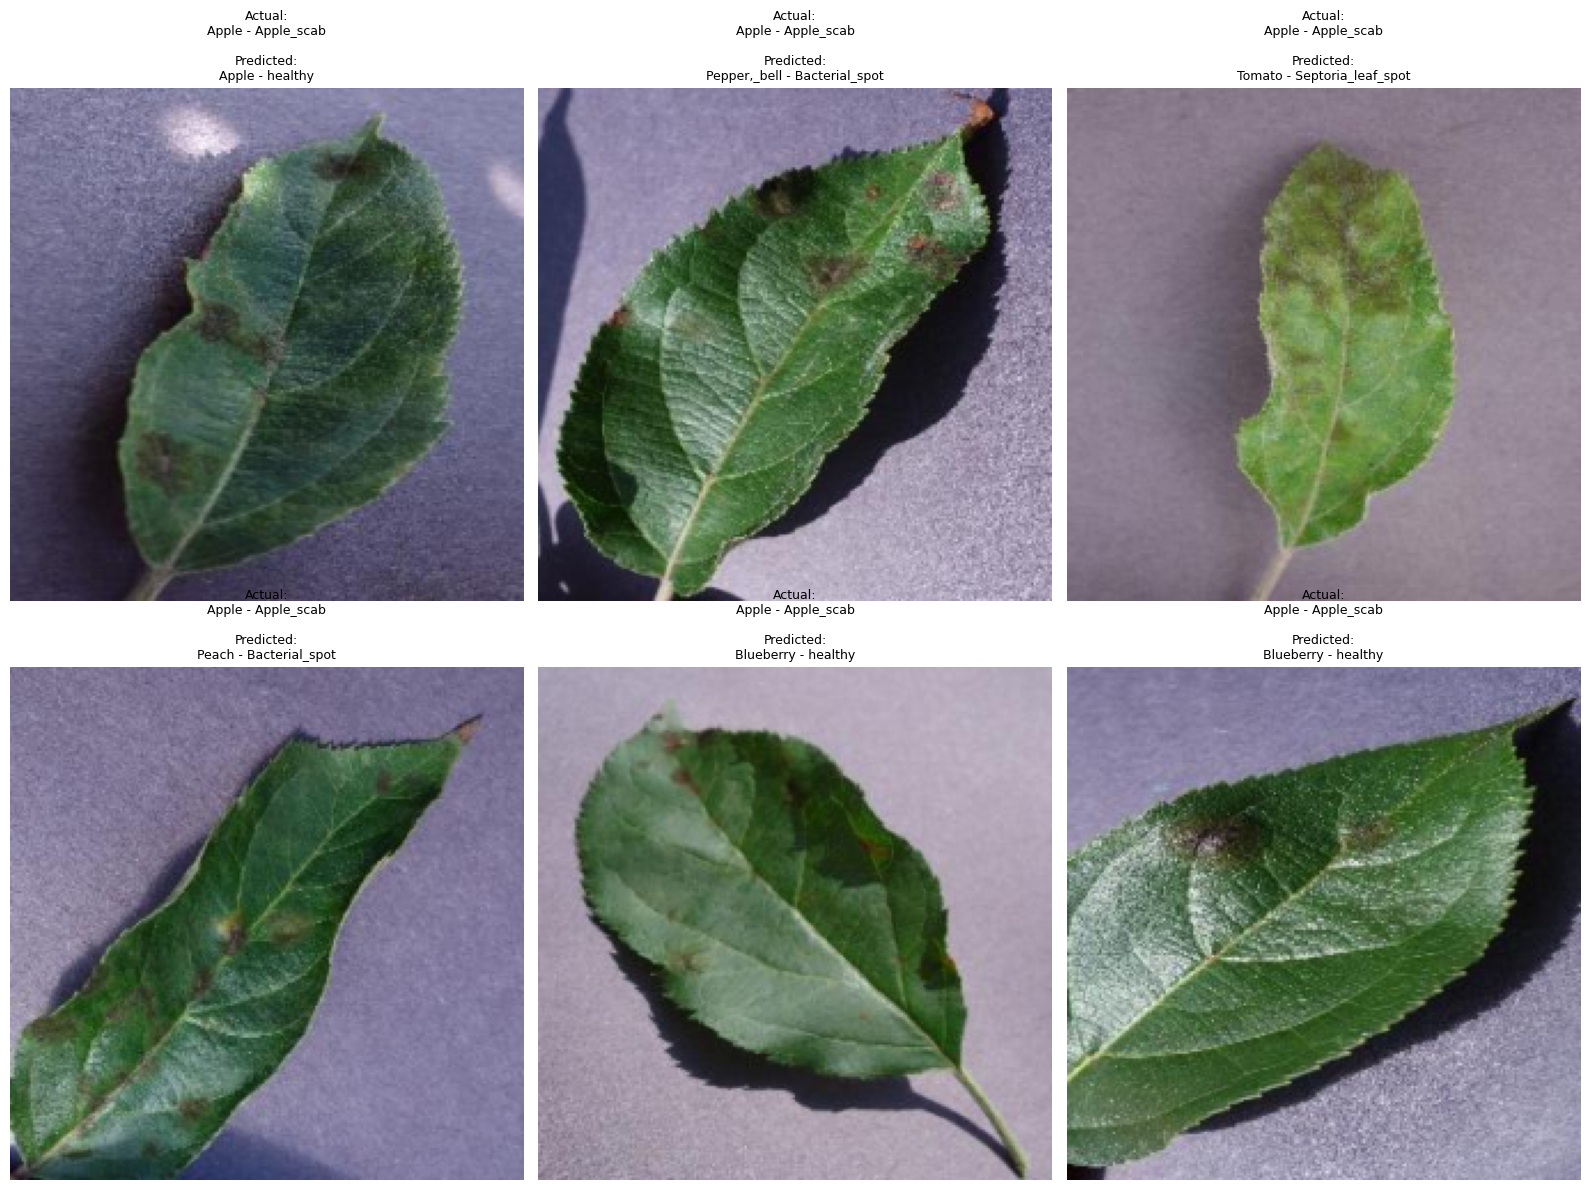

In [26]:
# Undo normalization so the images look normal

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

plt.figure(figsize=(16, 12))

for i in range(6):

    image = wrong_images[i] * std + mean

    # Keep pixel values between 0 and 1
    image = torch.clamp(image, 0, 1)

    # Change from PyTorch format to image format
    image = image.permute(1, 2, 0)

    plt.subplot(2, 3, i + 1)

    plt.imshow(image)

    actual = wrong_actual[i].replace("___", " - ")
    predicted = wrong_predicted[i].replace("___", " - ")

    plt.title(
        f"Actual:\n{actual}\n\nPredicted:\n{predicted}",
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [27]:
from torchvision import models
import torch.nn as nn

# Load ResNet18 with pretrained ImageNet weights
resnet_model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

print("Pretrained ResNet18 loaded!")

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 66.3MB/s]


Pretrained ResNet18 loaded!


In [28]:
# Freeze all pretrained ResNet layers

for parameter in resnet_model.parameters():
    parameter.requires_grad = False

print("Pretrained ResNet layers frozen!")

Pretrained ResNet layers frozen!


In [29]:
# Number of input features going into ResNet's final layer
num_features = resnet_model.fc.in_features

# Replace the old final layer with our 38-class layer
resnet_model.fc = nn.Linear(
    num_features,
    len(train_dataset.classes)
)

# Move ResNet to GPU
resnet_model = resnet_model.to(device)

print("ResNet18 ready!")
print("Number of output classes:", resnet_model.fc.out_features)
print("Device:", device)

ResNet18 ready!
Number of output classes: 38
Device: cuda


In [30]:
images, labels = next(iter(train_loader))

images = images.to(device)

resnet_model.eval()

with torch.no_grad():
    outputs = resnet_model(images)

print("Input shape:", images.shape)
print("ResNet output shape:", outputs.shape)

Input shape: torch.Size([32, 3, 224, 224])
ResNet output shape: torch.Size([32, 38])


In [31]:
import torch.optim as optim

# Loss function
resnet_criterion = nn.CrossEntropyLoss()

# Only train the new final classification layer
resnet_optimizer = optim.Adam(
    resnet_model.fc.parameters(),
    lr=0.001
)

# Number of epochs
RESNET_EPOCHS = 5

print("ResNet training setup complete!")
print("Loss: CrossEntropyLoss")
print("Optimizer: Adam")
print("Learning rate: 0.001")
print("Epochs:", RESNET_EPOCHS)

ResNet training setup complete!
Loss: CrossEntropyLoss
Optimizer: Adam
Learning rate: 0.001
Epochs: 5


In [33]:
# Separate variables so we don't overwrite baseline CNN results

resnet_train_losses = []
resnet_val_losses = []

resnet_train_accuracies = []
resnet_val_accuracies = []


for epoch in range(RESNET_EPOCHS):

    # ==========================
    # TRAINING
    # ==========================

    resnet_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Clear old gradients
        resnet_optimizer.zero_grad()

        # Predictions
        outputs = resnet_model(images)

        # Loss
        loss = resnet_criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update final layer
        resnet_optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()


    resnet_train_loss = running_loss / len(train_loader)

    resnet_train_accuracy = (
        100 * correct / total
    )


    # ==========================
    # VALIDATION
    # ==========================

    resnet_model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = resnet_model(images)

            loss = resnet_criterion(
                outputs,
                labels
            )

            val_running_loss += loss.item()

            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


    resnet_val_loss = (
        val_running_loss / len(val_loader)
    )

    resnet_val_accuracy = (
        100 * val_correct / val_total
    )


    # ==========================
    # SAVE RESULTS
    # ==========================

    resnet_train_losses.append(
        resnet_train_loss
    )

    resnet_val_losses.append(
        resnet_val_loss
    )

    resnet_train_accuracies.append(
        resnet_train_accuracy
    )

    resnet_val_accuracies.append(
        resnet_val_accuracy
    )


    # ==========================
    # PRINT RESULTS
    # ==========================

    print(f"Epoch [{epoch + 1}/{RESNET_EPOCHS}]")

    print(
        f"Training Loss: "
        f"{resnet_train_loss:.4f}"
    )

    print(
        f"Training Accuracy: "
        f"{resnet_train_accuracy:.2f}%"
    )

    print(
        f"Validation Loss: "
        f"{resnet_val_loss:.4f}"
    )

    print(
        f"Validation Accuracy: "
        f"{resnet_val_accuracy:.2f}%"
    )

    print("-" * 40)


print("ResNet18 training finished!")

Epoch [1/5]
Training Loss: 0.5873
Training Accuracy: 86.39%
Validation Loss: 0.2201
Validation Accuracy: 93.98%
----------------------------------------
Epoch [2/5]
Training Loss: 0.2087
Training Accuracy: 94.08%
Validation Loss: 0.1594
Validation Accuracy: 95.25%
----------------------------------------
Epoch [3/5]
Training Loss: 0.1611
Training Accuracy: 95.10%
Validation Loss: 0.1416
Validation Accuracy: 95.72%
----------------------------------------
Epoch [4/5]
Training Loss: 0.1400
Training Accuracy: 95.68%
Validation Loss: 0.1442
Validation Accuracy: 95.57%
----------------------------------------
Epoch [5/5]
Training Loss: 0.1220
Training Accuracy: 96.17%
Validation Loss: 0.1322
Validation Accuracy: 95.79%
----------------------------------------
ResNet18 training finished!


In [34]:
torch.save(
    resnet_model.state_dict(),
    "/content/resnet18_plant_disease.pth"
)

print("ResNet18 saved successfully!")

ResNet18 saved successfully!


In [35]:
# STEP 20: Evaluate ResNet18 on the test dataset

resnet_model.eval()

resnet_test_correct = 0
resnet_test_total = 0
resnet_test_running_loss = 0.0

resnet_all_labels = []
resnet_all_predictions = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)
        labels = labels.to(device)

        # Make predictions
        outputs = resnet_model(images)

        # Calculate loss
        loss = resnet_criterion(outputs, labels)
        resnet_test_running_loss += loss.item()

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        resnet_test_total += labels.size(0)

        resnet_test_correct += (
            predicted == labels
        ).sum().item()

        # Save results for later analysis
        resnet_all_labels.extend(
            labels.cpu().numpy()
        )

        resnet_all_predictions.extend(
            predicted.cpu().numpy()
        )


resnet_test_loss = (
    resnet_test_running_loss / len(test_loader)
)

resnet_test_accuracy = (
    100 * resnet_test_correct / resnet_test_total
)


print("RESNET18 TEST RESULTS")
print("----------------------------")
print(f"Test Loss: {resnet_test_loss:.4f}")
print(f"Test Accuracy: {resnet_test_accuracy:.2f}%")
print(f"Correct Predictions: {resnet_test_correct}")
print(f"Total Test Images: {resnet_test_total}")

RESNET18 TEST RESULTS
----------------------------
Test Loss: 0.1302
Test Accuracy: 95.84%
Correct Predictions: 7839
Total Test Images: 8179


In [36]:
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

resnet_macro_precision = precision_score(
    resnet_all_labels,
    resnet_all_predictions,
    average="macro"
)

resnet_macro_recall = recall_score(
    resnet_all_labels,
    resnet_all_predictions,
    average="macro"
)

resnet_macro_f1 = f1_score(
    resnet_all_labels,
    resnet_all_predictions,
    average="macro"
)

resnet_weighted_f1 = f1_score(
    resnet_all_labels,
    resnet_all_predictions,
    average="weighted"
)

print("RESNET18 - OVERALL TEST METRICS")
print("--------------------------------")
print(f"Test Accuracy:      {resnet_test_accuracy:.2f}%")
print(f"Macro Precision:    {resnet_macro_precision:.4f}")
print(f"Macro Recall:       {resnet_macro_recall:.4f}")
print(f"Macro F1-score:     {resnet_macro_f1:.4f}")
print(f"Weighted F1-score:  {resnet_weighted_f1:.4f}")

RESNET18 - OVERALL TEST METRICS
--------------------------------
Test Accuracy:      95.84%
Macro Precision:    0.9516
Macro Recall:       0.9478
Macro F1-score:     0.9483
Weighted F1-score:  0.9582


In [37]:
print("MODEL COMPARISON")
print("------------------------------------------------")
print(f"{'Metric':<22} {'Baseline CNN':<15} {'ResNet18':<15}")
print("------------------------------------------------")

print(
    f"{'Test Accuracy':<22} "
    f"{test_accuracy:<15.2f} "
    f"{resnet_test_accuracy:<15.2f}"
)

print(
    f"{'Macro Precision':<22} "
    f"{macro_precision:<15.4f} "
    f"{resnet_macro_precision:<15.4f}"
)

print(
    f"{'Macro Recall':<22} "
    f"{macro_recall:<15.4f} "
    f"{resnet_macro_recall:<15.4f}"
)

print(
    f"{'Macro F1':<22} "
    f"{macro_f1:<15.4f} "
    f"{resnet_macro_f1:<15.4f}"
)

print(
    f"{'Weighted F1':<22} "
    f"{weighted_f1:<15.4f} "
    f"{resnet_weighted_f1:<15.4f}"
)

print("------------------------------------------------")

MODEL COMPARISON
------------------------------------------------
Metric                 Baseline CNN    ResNet18       
------------------------------------------------
Test Accuracy          93.74           95.84          
Macro Precision        0.9237          0.9516         
Macro Recall           0.9087          0.9478         
Macro F1               0.9128          0.9483         
Weighted F1            0.9362          0.9582         
------------------------------------------------


In [38]:
# STEP 23A: Training data augmentation

augmented_train_transform = transforms.Compose([

    # Resize image
    transforms.Resize((224, 224)),

    # Randomly flip some images
    transforms.RandomHorizontalFlip(p=0.5),

    # Small random rotation
    transforms.RandomRotation(15),

    # Slightly modify brightness and contrast
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    # Convert image to tensor
    transforms.ToTensor(),

    # Same normalization used previously
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Training augmentation created successfully!")

Training augmentation created successfully!


In [39]:
# Only TRAINING data gets augmentation

augmented_train_dataset = datasets.ImageFolder(
    train_dir,
    transform=augmented_train_transform
)

# Validation stays unchanged
augmented_val_dataset = datasets.ImageFolder(
    val_dir,
    transform=baseline_transform
)

# Test stays unchanged
augmented_test_dataset = datasets.ImageFolder(
    test_dir,
    transform=baseline_transform
)

print("Augmented training images:", len(augmented_train_dataset))
print("Validation images:", len(augmented_val_dataset))
print("Test images:", len(augmented_test_dataset))

Augmented training images: 37997
Validation images: 8129
Test images: 8179


In [40]:
augmented_train_loader = DataLoader(
    augmented_train_dataset,
    batch_size=32,
    shuffle=True,
    num_workers=2
)

augmented_val_loader = DataLoader(
    augmented_val_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

augmented_test_loader = DataLoader(
    augmented_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2
)

print("Augmented DataLoaders created!")

Augmented DataLoaders created!


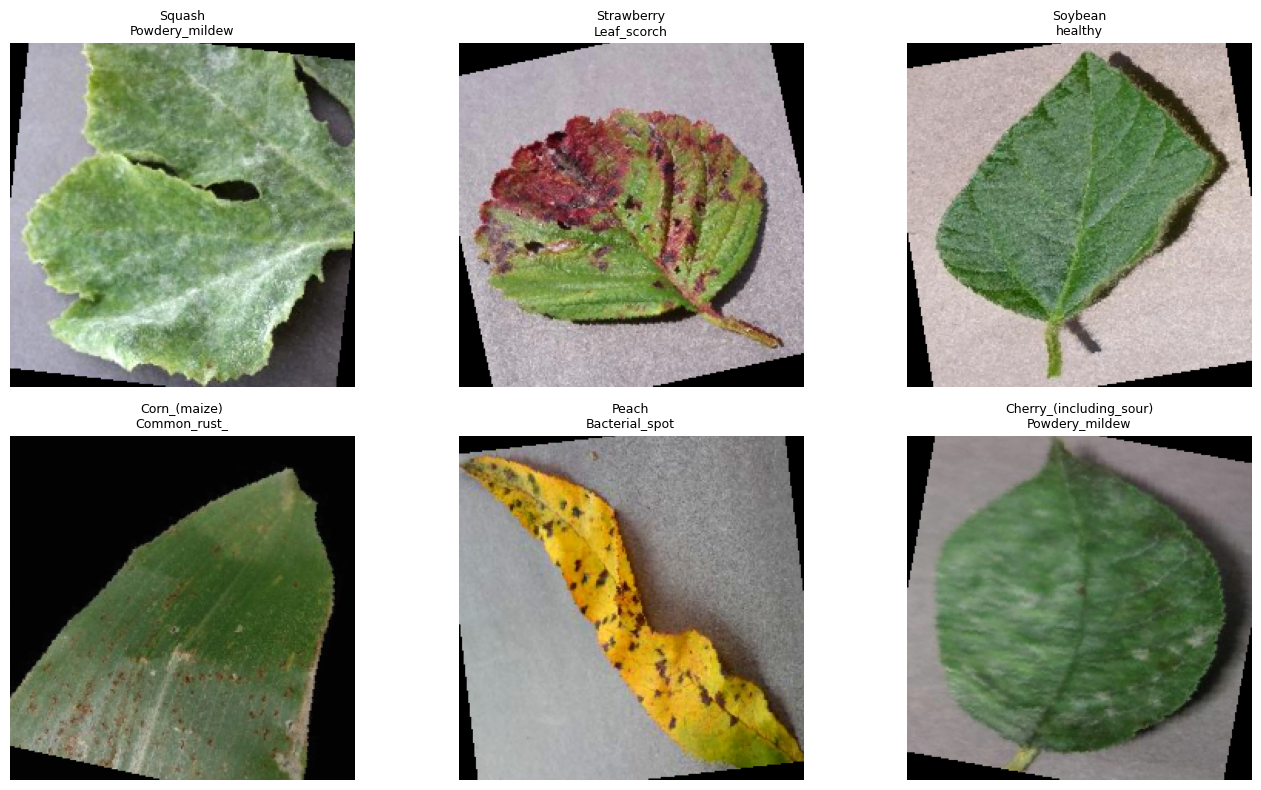

In [41]:
# Display augmented examples

images, labels = next(iter(augmented_train_loader))

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

plt.figure(figsize=(14, 8))

for i in range(6):

    image = images[i] * std + mean
    image = torch.clamp(image, 0, 1)
    image = image.permute(1, 2, 0)

    plt.subplot(2, 3, i + 1)
    plt.imshow(image)

    plt.title(
        augmented_train_dataset.classes[
            labels[i].item()
        ].replace("___", "\n"),
        fontsize=9
    )

    plt.axis("off")

plt.tight_layout()
plt.show()

In [42]:
from torchvision import models
import torch.nn as nn

# Load a fresh pretrained ResNet18
aug_resnet_model = models.resnet18(
    weights=models.ResNet18_Weights.DEFAULT
)

# Freeze pretrained layers
for param in aug_resnet_model.parameters():
    param.requires_grad = False

# Replace final layer for our 38 plant disease classes
num_features = aug_resnet_model.fc.in_features

aug_resnet_model.fc = nn.Linear(
    num_features,
    38
)

# Move model to GPU
aug_resnet_model = aug_resnet_model.to(device)

print("Fresh augmented ResNet18 created!")
print("Output classes:", aug_resnet_model.fc.out_features)
print("Device:", device)

Fresh augmented ResNet18 created!
Output classes: 38
Device: cuda


In [43]:
aug_criterion = nn.CrossEntropyLoss()

aug_optimizer = torch.optim.Adam(
    aug_resnet_model.fc.parameters(),
    lr=0.001
)

AUG_EPOCHS = 5

print("Augmented ResNet18 training setup complete!")
print("Epochs:", AUG_EPOCHS)
print("Learning rate: 0.001")

Augmented ResNet18 training setup complete!
Epochs: 5
Learning rate: 0.001


In [46]:
aug_train_losses = []
aug_val_losses = []

aug_train_accuracies = []
aug_val_accuracies = []


for epoch in range(AUG_EPOCHS):

    # =========================
    # TRAINING
    # =========================

    aug_resnet_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in augmented_train_loader:

        images = images.to(device)
        labels = labels.to(device)

        aug_optimizer.zero_grad()

        outputs = aug_resnet_model(images)

        loss = aug_criterion(outputs, labels)

        loss.backward()

        aug_optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()


    # Training results
    aug_train_loss = (
        running_loss / len(augmented_train_loader)
    )

    aug_train_accuracy = (
        100 * correct / total
    )


    # =========================
    # VALIDATION
    # =========================

    aug_resnet_model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for images, labels in augmented_val_loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = aug_resnet_model(images)

            loss = aug_criterion(
                outputs,
                labels
            )

            val_running_loss += loss.item()

            _, predicted = torch.max(
                outputs,
                1
            )

            val_total += labels.size(0)

            val_correct += (
                predicted == labels
            ).sum().item()


    aug_val_loss = (
        val_running_loss /
        len(augmented_val_loader)
    )

    aug_val_accuracy = (
        100 * val_correct / val_total
    )


    # =========================
    # SAVE RESULTS
    # =========================

    aug_train_losses.append(
        aug_train_loss
    )

    aug_val_losses.append(
        aug_val_loss
    )

    aug_train_accuracies.append(
        aug_train_accuracy
    )

    aug_val_accuracies.append(
        aug_val_accuracy
    )


    # =========================
    # PRINT EACH EPOCH
    # =========================

    print(f"Epoch [{epoch + 1}/{AUG_EPOCHS}]")

    print(
        f"Training Loss: {aug_train_loss:.4f}"
    )

    print(
        f"Training Accuracy: {aug_train_accuracy:.2f}%"
    )

    print(
        f"Validation Loss: {aug_val_loss:.4f}"
    )

    print(
        f"Validation Accuracy: {aug_val_accuracy:.2f}%"
    )

    print("-" * 45)


print("Augmented ResNet18 training finished!")

Epoch [1/5]
Training Loss: 0.1931
Training Accuracy: 93.76%
Validation Loss: 0.1685
Validation Accuracy: 94.59%
---------------------------------------------
Epoch [2/5]
Training Loss: 0.1878
Training Accuracy: 93.99%
Validation Loss: 0.1398
Validation Accuracy: 95.42%
---------------------------------------------
Epoch [3/5]
Training Loss: 0.1759
Training Accuracy: 94.20%
Validation Loss: 0.1512
Validation Accuracy: 95.25%
---------------------------------------------
Epoch [4/5]
Training Loss: 0.1745
Training Accuracy: 94.21%
Validation Loss: 0.1375
Validation Accuracy: 95.53%
---------------------------------------------
Epoch [5/5]
Training Loss: 0.1695
Training Accuracy: 94.24%
Validation Loss: 0.1557
Validation Accuracy: 94.92%
---------------------------------------------
Augmented ResNet18 training finished!


In [47]:
torch.save(
    aug_resnet_model.state_dict(),
    "/content/resnet18_augmented_plant_disease.pth"
)

print("Augmented ResNet18 saved successfully!")

Augmented ResNet18 saved successfully!


In [48]:
# STEP 25: Test Augmented ResNet18

aug_resnet_model.eval()

aug_test_correct = 0
aug_test_total = 0
aug_test_running_loss = 0.0

aug_all_labels = []
aug_all_predictions = []

with torch.no_grad():

    for images, labels in augmented_test_loader:

        # Move data to GPU
        images = images.to(device)
        labels = labels.to(device)

        # Make predictions
        outputs = aug_resnet_model(images)

        # Calculate loss
        loss = aug_criterion(outputs, labels)

        aug_test_running_loss += loss.item()

        # Get predicted class
        _, predicted = torch.max(outputs, 1)

        # Count correct predictions
        aug_test_total += labels.size(0)

        aug_test_correct += (
            predicted == labels
        ).sum().item()

        # Save labels and predictions
        aug_all_labels.extend(
            labels.cpu().numpy()
        )

        aug_all_predictions.extend(
            predicted.cpu().numpy()
        )


# Calculate final test loss
aug_test_loss = (
    aug_test_running_loss /
    len(augmented_test_loader)
)

# Calculate final test accuracy
aug_test_accuracy = (
    100 * aug_test_correct /
    aug_test_total
)


print("AUGMENTED RESNET18 TEST RESULTS")
print("--------------------------------")

print(
    f"Test Loss: {aug_test_loss:.4f}"
)

print(
    f"Test Accuracy: {aug_test_accuracy:.2f}%"
)

print(
    f"Correct Predictions: {aug_test_correct}"
)

print(
    f"Total Test Images: {aug_test_total}"
)

AUGMENTED RESNET18 TEST RESULTS
--------------------------------
Test Loss: 0.1593
Test Accuracy: 94.72%
Correct Predictions: 7747
Total Test Images: 8179


In [49]:
# STEP 26: Augmented ResNet18 metrics

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score
)

aug_macro_precision = precision_score(
    aug_all_labels,
    aug_all_predictions,
    average="macro"
)

aug_macro_recall = recall_score(
    aug_all_labels,
    aug_all_predictions,
    average="macro"
)

aug_macro_f1 = f1_score(
    aug_all_labels,
    aug_all_predictions,
    average="macro"
)

aug_weighted_f1 = f1_score(
    aug_all_labels,
    aug_all_predictions,
    average="weighted"
)


print("AUGMENTED RESNET18 - OVERALL METRICS")
print("-------------------------------------")

print(
    f"Test Accuracy:     {aug_test_accuracy:.2f}%"
)

print(
    f"Macro Precision:   {aug_macro_precision:.4f}"
)

print(
    f"Macro Recall:      {aug_macro_recall:.4f}"
)

print(
    f"Macro F1-score:    {aug_macro_f1:.4f}"
)

print(
    f"Weighted F1-score: {aug_weighted_f1:.4f}"
)

AUGMENTED RESNET18 - OVERALL METRICS
-------------------------------------
Test Accuracy:     94.72%
Macro Precision:   0.9413
Macro Recall:      0.9299
Macro F1-score:    0.9327
Weighted F1-score: 0.9471


In [50]:
# STEP 27: Compare all three models

print("FINAL MODEL COMPARISON")
print("-" * 75)

print(
    f"{'Metric':<20}"
    f"{'Baseline CNN':<18}"
    f"{'ResNet18':<18}"
    f"{'ResNet18 + Aug':<18}"
)

print("-" * 75)

print(
    f"{'Test Accuracy':<20}"
    f"{test_accuracy:<18.2f}"
    f"{resnet_test_accuracy:<18.2f}"
    f"{aug_test_accuracy:<18.2f}"
)

print(
    f"{'Macro Precision':<20}"
    f"{macro_precision:<18.4f}"
    f"{resnet_macro_precision:<18.4f}"
    f"{aug_macro_precision:<18.4f}"
)

print(
    f"{'Macro Recall':<20}"
    f"{macro_recall:<18.4f}"
    f"{resnet_macro_recall:<18.4f}"
    f"{aug_macro_recall:<18.4f}"
)

print(
    f"{'Macro F1':<20}"
    f"{macro_f1:<18.4f}"
    f"{resnet_macro_f1:<18.4f}"
    f"{aug_macro_f1:<18.4f}"
)

print(
    f"{'Weighted F1':<20}"
    f"{weighted_f1:<18.4f}"
    f"{resnet_weighted_f1:<18.4f}"
    f"{aug_weighted_f1:<18.4f}"
)

print("-" * 75)

FINAL MODEL COMPARISON
---------------------------------------------------------------------------
Metric              Baseline CNN      ResNet18          ResNet18 + Aug    
---------------------------------------------------------------------------
Test Accuracy       93.74             95.84             94.72             
Macro Precision     0.9237            0.9516            0.9413            
Macro Recall        0.9087            0.9478            0.9299            
Macro F1            0.9128            0.9483            0.9327            
Weighted F1         0.9362            0.9582            0.9471            
---------------------------------------------------------------------------


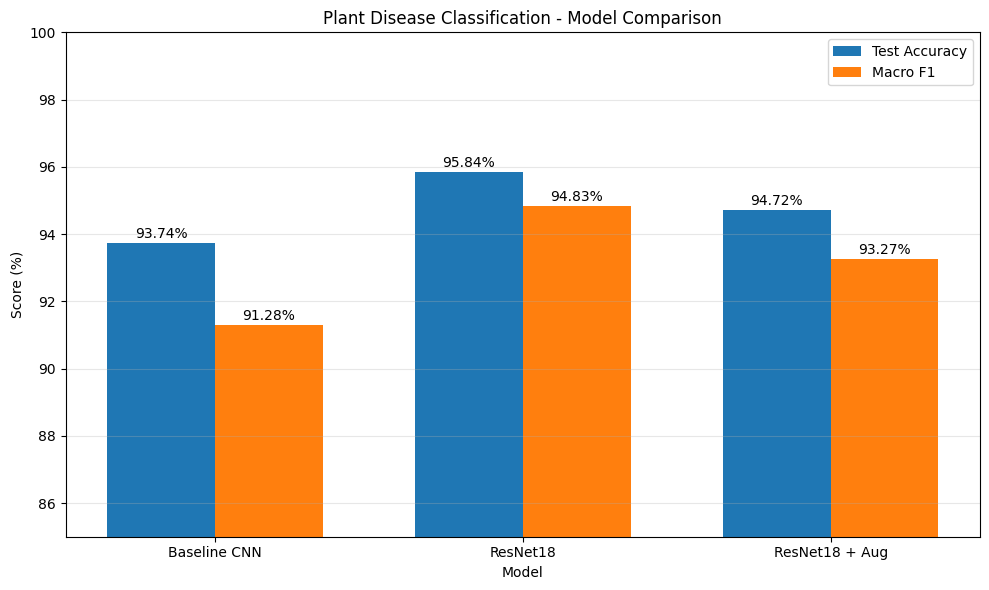

In [51]:
# STEP 28: Final model comparison graph

import matplotlib.pyplot as plt
import numpy as np

models = [
    "Baseline CNN",
    "ResNet18",
    "ResNet18 + Aug"
]

accuracy_scores = [
    test_accuracy,
    resnet_test_accuracy,
    aug_test_accuracy
]

macro_f1_scores = [
    macro_f1 * 100,
    resnet_macro_f1 * 100,
    aug_macro_f1 * 100
]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(10, 6))

bars1 = plt.bar(
    x - width/2,
    accuracy_scores,
    width,
    label="Test Accuracy"
)

bars2 = plt.bar(
    x + width/2,
    macro_f1_scores,
    width,
    label="Macro F1"
)

plt.ylabel("Score (%)")
plt.xlabel("Model")

plt.title(
    "Plant Disease Classification - Model Comparison"
)

plt.xticks(x, models)

plt.ylim(85, 100)

plt.legend()
plt.grid(axis="y", alpha=0.3)

# Add numbers above bars
for bar in bars1:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.15,
        f"{height:.2f}%",
        ha="center"
    )

for bar in bars2:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + 0.15,
        f"{height:.2f}%",
        ha="center"
    )

plt.tight_layout()
plt.show()

## Experimental Results and Model Comparison

Three deep-learning configurations were evaluated on the same held-out test set of 8,179 plant leaf images.

### 1. Baseline CNN
The custom baseline CNN achieved a test accuracy of **93.74%**, with a macro F1-score of **0.9128**.

### 2. Transfer Learning with ResNet18
A pretrained ResNet18 model was adapted to classify the 38 PlantVillage categories. It achieved a test accuracy of **95.84%** and a macro F1-score of **0.9483**, improving over the baseline CNN.

### 3. ResNet18 with Data Augmentation
The ResNet18 model was also trained using random horizontal flipping, rotation, and color jitter. This configuration achieved **94.72%** test accuracy and a macro F1-score of **0.9327**.

### Interpretation

In these experiments, the non-augmented ResNet18 achieved the highest test accuracy and macro F1-score. Transfer learning therefore improved performance relative to the custom baseline CNN.

The augmentation configuration did not improve performance over the non-augmented ResNet18 under the augmentation settings and five-epoch training procedure used here. This result demonstrates why augmentation should be evaluated experimentally rather than assumed to improve model performance.

In [52]:
# STEP 30: Detailed classification report for ResNet18

from sklearn.metrics import classification_report

class_names = test_dataset.classes

report = classification_report(
    resnet_all_labels,
    resnet_all_predictions,
    target_names=class_names,
    digits=4
)

print("RESNET18 - CLASSIFICATION REPORT")
print("=" * 80)
print(report)

RESNET18 - CLASSIFICATION REPORT
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9570    0.9368    0.9468        95
                                 Apple___Black_rot     0.9891    0.9681    0.9785        94
                          Apple___Cedar_apple_rust     1.0000    0.9762    0.9880        42
                                   Apple___healthy     0.9280    0.9879    0.9570       248
                               Blueberry___healthy     1.0000    0.9690    0.9843       226
          Cherry_(including_sour)___Powdery_mildew     0.9812    0.9874    0.9843       159
                 Cherry_(including_sour)___healthy     0.9921    0.9767    0.9844       129
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.6916    0.9487    0.8000        78
                       Corn_(maize)___Common_rust_     0.9836    1.0000    0.9917       180
               Corn_(maize)___Northern_Leaf_Bl

In [53]:
# STEP 31: Find strongest and weakest ResNet18 classes

import pandas as pd
from sklearn.metrics import classification_report

report_dict = classification_report(
    resnet_all_labels,
    resnet_all_predictions,
    target_names=class_names,
    output_dict=True
)

class_results = []

for class_name in class_names:

    class_results.append({
        "Class": class_name,
        "Precision": report_dict[class_name]["precision"],
        "Recall": report_dict[class_name]["recall"],
        "F1-score": report_dict[class_name]["f1-score"],
        "Support": report_dict[class_name]["support"]
    })

results_df = pd.DataFrame(class_results)

# Sort from lowest F1 to highest F1
results_df = results_df.sort_values(
    by="F1-score",
    ascending=True
)

print("5 LOWEST PERFORMING CLASSES")
print("=" * 80)

print(
    results_df.head(5).to_string(
        index=False
    )
)

print("\n5 HIGHEST PERFORMING CLASSES")
print("=" * 80)

print(
    results_df.tail(5)
    .sort_values(
        by="F1-score",
        ascending=False
    )
    .to_string(index=False)
)

5 LOWEST PERFORMING CLASSES
                                             Class  Precision   Recall  F1-score  Support
                             Tomato___Early_blight   0.794521 0.773333  0.783784    150.0
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot   0.691589 0.948718  0.800000     78.0
               Corn_(maize)___Northern_Leaf_Blight   0.957983 0.765101  0.850746    149.0
                              Tomato___Target_Spot   0.927778 0.787736  0.852041    212.0
                              Tomato___Late_blight   0.942387 0.797909  0.864151    287.0

5 HIGHEST PERFORMING CLASSES
                                     Class  Precision   Recall  F1-score  Support
Grape___Leaf_blight_(Isariopsis_Leaf_Spot)   1.000000 1.000000  1.000000    162.0
                    Corn_(maize)___healthy   1.000000 1.000000  1.000000    175.0
  Orange___Haunglongbing_(Citrus_greening)   0.996381 0.998791  0.997585    827.0
                   Squash___Powdery_mildew   0.996377 0.996377  0.996377  

## Failure Analysis

Although ResNet18 achieved strong overall performance, the per-class evaluation shows that performance varies across disease categories.

The lowest F1-score was observed for **Tomato Early Blight (0.7838)**. Other relatively difficult classes included **Corn Cercospora Leaf Spot / Gray Leaf Spot (0.8000)**, **Corn Northern Leaf Blight (0.8507)**, **Tomato Target Spot (0.8520)**, and **Tomato Late Blight (0.8642)**.

The confusion analysis performed earlier also showed that some errors occurred between disease categories belonging to the same plant species. This suggests that visually similar disease symptoms can be challenging for the classifier to distinguish.

In contrast, several classes achieved very high performance. **Grape Leaf Blight** and **Corn Healthy** achieved an F1-score of 1.0000 on this test split.

These results demonstrate why overall accuracy alone is not sufficient for evaluating a multi-class classifier. Per-class precision, recall, F1-score, confusion analysis, and examination of misclassified images provide a more complete understanding of model performance.

Class imbalance may also be relevant when interpreting the results because the PlantVillage categories contain substantially different numbers of images. However, the current experiment does not establish class imbalance as the cause of any particular classification error.

In [54]:
# STEP 33: Save selected final model

torch.save(
    resnet_model.state_dict(),
    "/content/best_plant_disease_resnet18.pth"
)

print("Final ResNet18 model saved!")
print("Test Accuracy: 95.84%")
print("Macro F1-score: 0.9483")

Final ResNet18 model saved!
Test Accuracy: 95.84%
Macro F1-score: 0.9483


In [55]:
# STEP 34: Function for predicting one leaf image

from PIL import Image
import torch

def predict_leaf_image(image_path):

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Apply same preprocessing used for testing
    input_tensor = baseline_transform(image)

    # Add batch dimension
    input_tensor = input_tensor.unsqueeze(0)

    # Move to GPU
    input_tensor = input_tensor.to(device)

    # Evaluation mode
    resnet_model.eval()

    # Prediction
    with torch.no_grad():

        output = resnet_model(input_tensor)

        probabilities = torch.softmax(output, dim=1)

        confidence, predicted_index = torch.max(
            probabilities,
            1
        )

    predicted_class = class_names[
        predicted_index.item()
    ]

    confidence = confidence.item() * 100

    print("Predicted class:")
    print(predicted_class)

    print(
        f"\nConfidence: {confidence:.2f}%"
    )

    return predicted_class, confidence


print("Single-image prediction function ready!")

Single-image prediction function ready!


In [57]:
# STEP 35: Upload a leaf image for prediction

from google.colab import files

uploaded = files.upload()

image_path = next(iter(uploaded))

print("Uploaded image:", image_path)

Saving tomato_leaf.png to tomato_leaf.png
Uploaded image: tomato_leaf.png


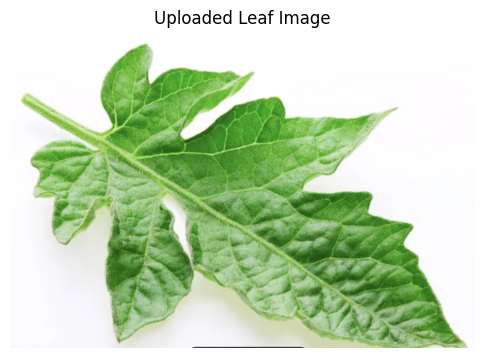

In [58]:
# STEP 36: Display uploaded image

from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(image_path).convert("RGB")

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Uploaded Leaf Image")
plt.show()

In [59]:
# STEP 37: Predict disease

predicted_class, confidence = predict_leaf_image(image_path)

Predicted class:
Tomato___Late_blight

Confidence: 40.19%


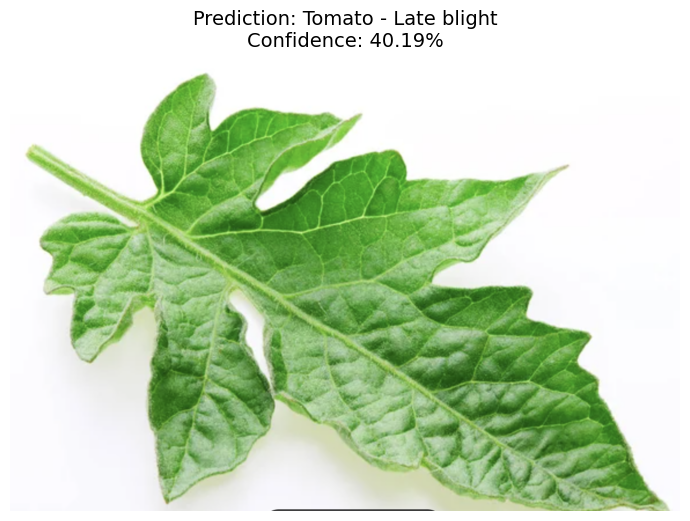

In [60]:
# STEP 38: Display final prediction result

from PIL import Image
import matplotlib.pyplot as plt

image = Image.open(image_path).convert("RGB")

display_name = predicted_class.replace("___", " - ").replace("_", " ")

plt.figure(figsize=(7, 6))
plt.imshow(image)
plt.axis("off")

plt.title(
    f"Prediction: {display_name}\n"
    f"Confidence: {confidence:.2f}%",
    fontsize=14
)

plt.tight_layout()
plt.show()

### Single-Image Prediction

The final ResNet18 model was tested on an individual plant leaf image outside the held-out test set. The model predicted **Tomato - Late blight** with a confidence score of **40.19%**.

The relatively low confidence indicates that the model was uncertain about this image. One possible explanation is a difference between the appearance of the external image and the PlantVillage training data, such as background, lighting, leaf orientation, or image characteristics. This demonstrates an important limitation of image-classification models: strong performance on a held-out dataset does not necessarily guarantee equally confident predictions on images from different sources.

# Final Conclusion

This project developed and evaluated deep-learning models for multiclass plant disease classification using the PlantVillage dataset. The dataset contained **54,305 images across 38 classes** and was divided into approximately **70% training, 15% validation, and 15% testing data**.

Three model configurations were evaluated:

| Model | Test Accuracy | Macro F1 |
|---|---:|---:|
| Baseline CNN | 93.74% | 91.28% |
| ResNet18 | 95.84% | 94.83% |
| ResNet18 + Augmentation | 94.72% | 93.27% |

The baseline CNN achieved strong classification performance, but transfer learning with **ResNet18 produced the strongest test results**, reaching **95.84% test accuracy** and a **94.83% Macro F1-score**.

The augmentation experiment did not improve performance in this experiment. ResNet18 with augmentation achieved 94.72% accuracy, compared with 95.84% without augmentation. This demonstrates that augmentation does not automatically improve model performance and should be evaluated experimentally.

Class-level evaluation and failure analysis also showed that performance varied between disease categories. Some visually similar classes were more difficult for the model to distinguish, emphasizing the importance of examining precision, recall, F1-score, confusion patterns, and individual misclassified images rather than relying only on overall accuracy.

Finally, the selected ResNet18 model was tested on an external leaf image. It predicted **Tomato - Late blight** with **40.19% confidence**. The relatively low confidence suggests that performance on external images can differ from performance on the held-out PlantVillage test set.

Overall, the experiments demonstrate that transfer learning with ResNet18 can provide strong performance for plant disease image classification while also highlighting challenges related to class imbalance, generalization, and confidence on images outside the original dataset.

## Future Work

Future improvements could include collecting more diverse real-world plant images, addressing class imbalance, testing additional augmentation strategies, and comparing other pretrained architectures such as EfficientNet or DenseNet. Model generalization could also be improved by training with images containing different backgrounds, lighting conditions, camera angles, and disease stages.

For practical deployment, future work could include confidence-based warnings for uncertain predictions and a simple web or mobile application that allows users to upload a leaf image and receive a predicted disease class.